<a href="https://colab.research.google.com/github/izhanys/PBA_Bima_5026231060/blob/main/Tugas/Week%203/Week_3_2_Yearly_Bima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reviews Per Year Analysis Google Apps Review-Bima+

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('indonesian'))

In [2]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df):,} rows')
df.head()

Saving review_bima_75000.csv to review_bima_75000.csv
Loaded: 75,000 rows


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,64cf8bb2-43bd-430d-9cde-b23fba4a5d16,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Try gblok gajelas kontl,5,0,NaN,2026-03-10 04:20:37,NaN,NaN,NaN
1,b224d50f-2c03-422f-a632-be4eea88f29a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,jangan mahal2 harganya,5,0,NaN,2026-03-10 03:45:42,NaN,NaN,NaN
2,435972c2-7a26-436d-ba68-89cba47a9c60,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,mantap,5,0,5.12.0,2026-03-10 03:42:26,NaN,NaN,5.12.0
3,41d826a3-1411-4b29-ba43-e3ea2fbd01f8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tri terbaik,4,0,5.13.0,2026-03-10 03:39:43,NaN,NaN,5.13.0
4,e3c550aa-841a-457a-a9cf-218e495ea6cc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat bgs,5,0,5.12.0,2026-03-10 03:28:51,NaN,NaN,5.12.0


Descriptive Statistics

/tmp/ipykernel_13085/4266982433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


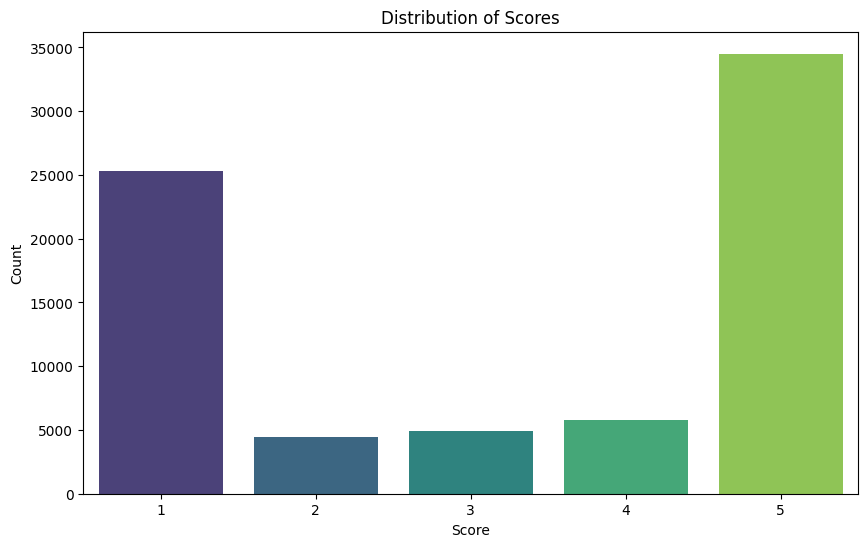

In [3]:
score_counts = df['score'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

Reviews per Year

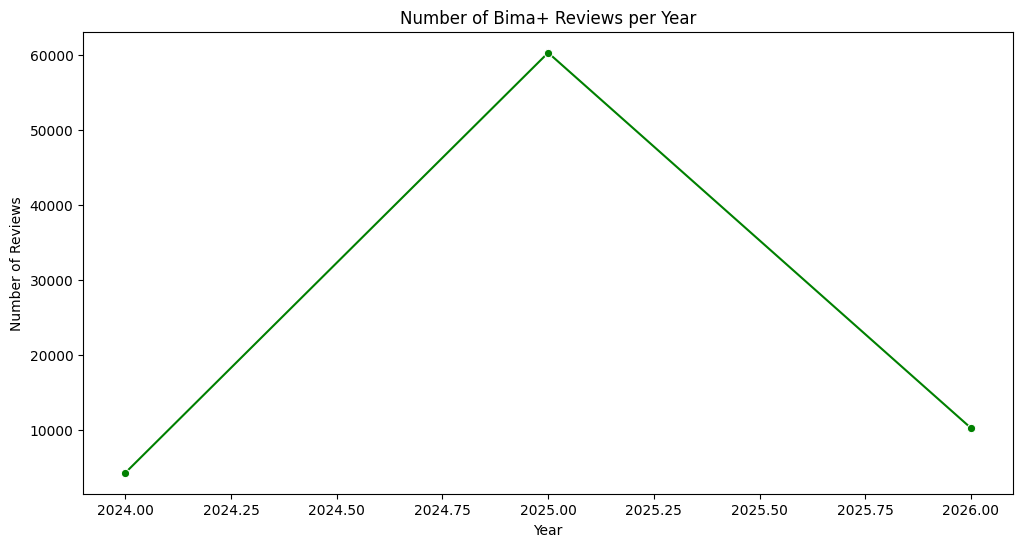

In [5]:
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of Bima+ Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

In [6]:
Score Distribution by Year

SyntaxError: invalid syntax (4159456103.py, line 1)

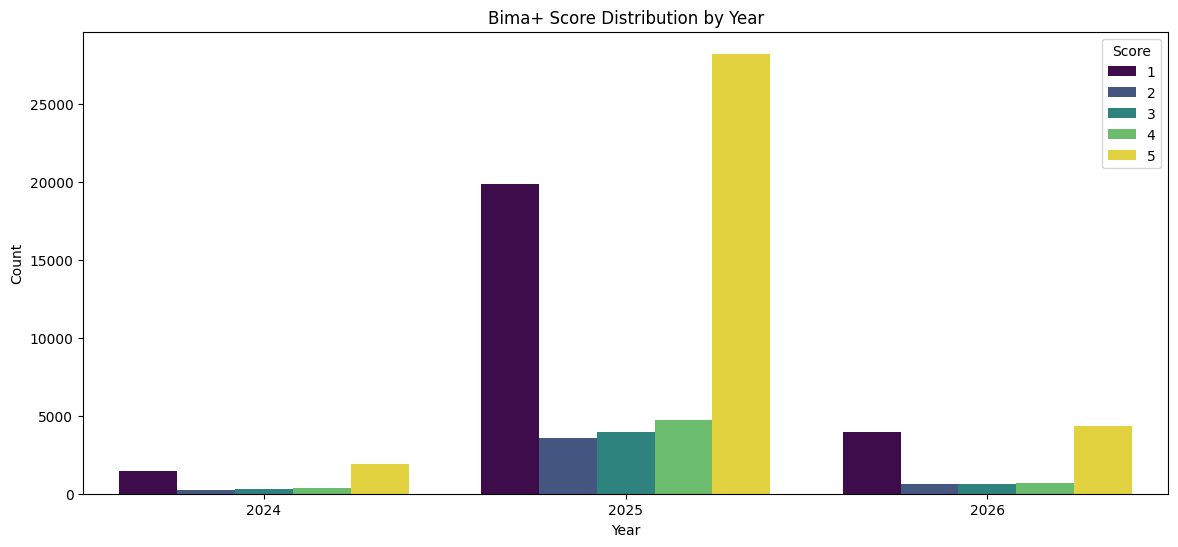

In [8]:
plt.figure(figsize=(14, 6))
sns.countplot(x='year', hue='score', data=df, palette='viridis')
plt.title('Bima+ Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

Word Cloud (Positive vs Negative)

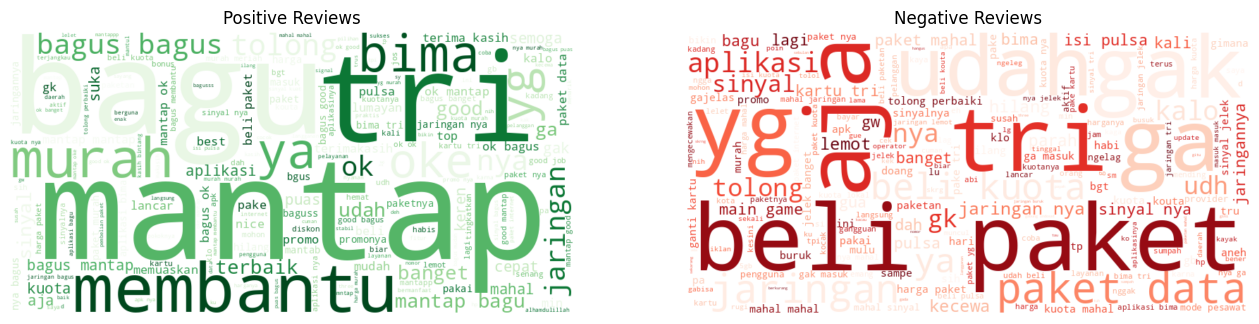

In [9]:
df['sentiment'] = df['score'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

def remove_stopwords(text):
    words = str(text).lower().split()
    return ' '.join([w for w in words if w not in stop_words])

pos_text = ' '.join(df[df['sentiment'] == 'positive']['content'].dropna().apply(remove_stopwords))
neg_text = ' '.join(df[df['sentiment'] == 'negative']['content'].dropna().apply(remove_stopwords))

pos_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
neg_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].set_title('Positive Reviews')
axes[0].axis('off')
axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].set_title('Negative Reviews')
axes[1].axis('off')
plt.show()